In [1]:
import numpy as np
import os
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
import pickle

from spectral.io import envi
from spectral.io.envi import read_envi_header

from isofit.core.fileio import IO
from isofit.core.forward import ForwardModel
from isofit.inversion.inverse import Inversion
from isofit.inversion.inverse_simple import invert_algebraic, invert_simple
from isofit.configs import configs
from isofit.core.geometry import Geometry
from isofit.radiative_transfer.radiative_transfer import RadiativeTransfer
from isofit.radiative_transfer import luts
import logging

# Enable the ISOFIT logger
logging.getLogger().setLevel(logging.INFO)

%matplotlib widget

In [19]:
home = '/store/carroll/col/data/'
extra_data = '/store/carroll/col/data/'
out_figs = '/store/carroll/col/figs/'

wl = np.loadtxt('/store/carroll/col/data/2018/test_roi/calTarp/NIS01_20180611_172310_sRTMnet_20250806/data/wavelengths.txt')[:,1]*1000
def closest_wl(mv):
    return np.argmin(np.abs(wl-mv))
wl_nan = wl.copy()
wl_nan[closest_wl(1360):closest_wl(1410)] = np.nan
wl_nan[closest_wl(1800):closest_wl(1970)] = np.nan

# prepare representative single pxs
fp_single_px = '/store/carroll/col/data/2018/test_roi/single_pxs.pkl'
with open(fp_single_px, 'rb') as f:
    single_px = pickle.load(f)
rdn = single_px['rdn']
obs = single_px['obs']
loc = single_px['loc']

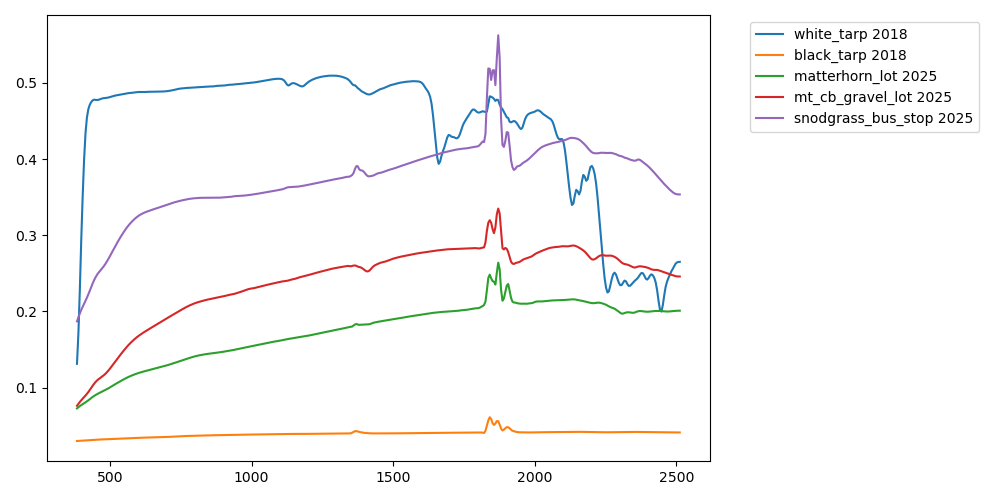

In [3]:
# load pre-processed insitu data
insitu = pd.read_csv(home+'cal_spec_20182025_neon.csv')

fig = plt.figure(figsize=(10,5))
for idx, row in insitu.iterrows():
    rfl = row[2:]
    plt.plot(wl, rfl, label=f'{row['site']} {row['year']}')
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [5]:
# derive factors - loop through all flightlines for black, white tarp representative single pixels

# set up dict to hold outputs 
modeled_rdns = {k: {} for k in rdn.keys()}
rccs = {k: {} for k in rdn.keys()}

# define global parameters
version = '20250806'
fol = home+'2018/test_roi/calTarp/'
fp_surface = os.path.join(home, '2018/test_roi/surface_20240103_avirii_20250730.mat')
fp_noise = extra_data + 'avirisng_noise_neon.txt'
integrations = 2
fp_channelized_radiometric_uncertainty = extra_data + 'avirisng_systematic_error_neon.txt'
# fp_model_discrepancy = extra_data + 'avirisng_model_discrepancy_neon.mat'

for flight in rdn.keys():
    for k in ['white_tarp', 'black_tarp']:
        
        try:
            # load, update config file
            fp_config = glob(os.path.join(fol, f'{flight}*{version}', 'config', '*_isofit.json'))[0]
            config = configs.create_new_config(fp_config)
            config.forward_model.surface.surface_file = fp_surface
            config.input.measured_radiance_file = glob(os.path.join(fol, 'subset', f'{flight}_rdn'))[0]
            config.input.obs_file = glob(os.path.join(fol, 'subset', f'{flight}_obs'))[0]
            config.input.loc_file = glob(os.path.join(fol, 'subset', f'{flight}_igm'))[0]
            
            # borrow the avirisng instrument model, updated to neon wavelengths
            config.forward_model.instrument.parametric_noise_file = fp_noise
            config.forward_model.instrument.integrations = integrations 
            config.forward_model.instrument.unknowns.channelized_radiometric_uncertainty_file = fp_channelized_radiometric_uncertainty
            # config.forward_model.model_discrepancy_file = fp_model_discrepancy
          
            print('\n', flight, k)
            
            # set up forward model, io, inv according to config
            fm = ForwardModel(config) # loads pre-built LUT
            io = IO(config, fm)
            inv = Inversion(config, fm)
            
            # load the isofit geometry representation of the single pixel
            rdn_ = rdn[flight][k]
            obs_ = obs[flight][k]
            loc_ = loc[flight][k]
            geom = Geometry(obs=obs_, loc=loc_)
            geom.sky_view_factor = 1
            
            # run the iterative inversions, each adjusting the state vector at each step to minimize the loss function comparing predicted and observed rdn
            states=inv.invert(rdn_, geom)
            x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])
            x_alg, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, x_surface, x_RT, x_instrument, rdn_, geom)
   
            # get single px rcc
            fp_rfl = home + f'2018/insitu/cal_{k}_neon.txt'
            insitu_rfl = np.loadtxt(fp_rfl)[:,1]
            modeled_rdn = fm.calc_meas(np.concatenate([x_alg, x_RT, x_instrument]), geom, insitu_rfl)
            rcc_ = modeled_rdn/rdn_

            rccs[flight][k] = rcc_
            modeled_rdns[flight][k] = modeled_rdn
            
        except Exception as e:
            print(f"Error for flight {flight}, key {k}: {e}")

INFO:root:Loading config file: /store/carroll/col/data/2018/test_roi/calTarp/NIS01_20180611_172310_sRTMnet_20250806/config/NIS01_20180611_172310_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/2018/test_roi/calTarp/NIS01_20180611_172310_sRTMnet_20250806/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided



 NIS01_20180611_172310 white_tarp


INFO:isofit.radiative_transfer.luts:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file
INFO:root:Loading config file: /store/carroll/col/data/2018/test_roi/calTarp/NIS01_20180611_172310_sRTMnet_20250806/config/NIS01_20180611_172310_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/2018/test_roi/calTarp/NIS01_20180611_172310_sRTMnet_20250806/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided



 NIS01_20180611_172310 black_tarp


INFO:isofit.radiative_transfer.luts:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file
INFO:root:Loading config file: /store/carroll/col/data/2018/test_roi/calTarp/NIS01_20180611_172711_sRTMnet_20250806/config/NIS01_20180611_172711_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/2018/test_roi/calTarp/NIS01_20180611_172711_sRTMnet_20250806/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided


...

Error for flight NIS01_20180611_173116, key black_tarp: [Errno 2] No such file or directory: '/store/carroll/data/col/2018/test_roi/calTarp/NIS01_20180611_173116_sRTMnet_20250806/output/NIS01_20180611_173116_uncert'

 NIS01_20180611_173537 white_tarp


INFO:isofit.radiative_transfer.luts:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file
INFO:root:Loading config file: /store/carroll/col/data/2018/test_roi/calTarp/NIS01_20180611_173537_sRTMnet_20250806/config/NIS01_20180611_173537_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/2018/test_roi/calTarp/NIS01_20180611_173537_sRTMnet_20250806/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided



 NIS01_20180611_173537 black_tarp


INFO:isofit.radiative_transfer.luts:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file


Error for flight NIS01_20180619_172934, key white_tarp: list index out of range
Error for flight NIS01_20180619_172934, key black_tarp: list index out of range
Error for flight NIS01_20180619_160339, key white_tarp: list index out of range
Error for flight NIS01_20180619_160339, key black_tarp: list index out of range


In [ ]:
# save all of the rccs

rccs

fp_out = home + '2018/test_roi/rccs_white_tarp_20250829.pkl'

with open(fp_out, 'wb') as f:
    pickle.dump(rccs, f)

In [11]:
# calculate, save mean factors for white tarp
rcc_white_tarp_mean = []
for flight in rccs.keys():
    try:
        rcc_ = rccs[flight]['white_tarp']
        rcc_white_tarp_mean.append(rcc_)
    except: pass
rcc_white_tarp_mean = np.stack(rcc_white_tarp_mean, axis=0)
rcc_white_tarp_mean = np.mean(rcc_white_tarp_mean, axis=0)

# # save them so can input them later...
# fp_out = home + '2018/test_roi/rcc_white_tarp_mean_20250829.txt'
# np.savetxt(fp_out, rcc_white_tarp_mean)

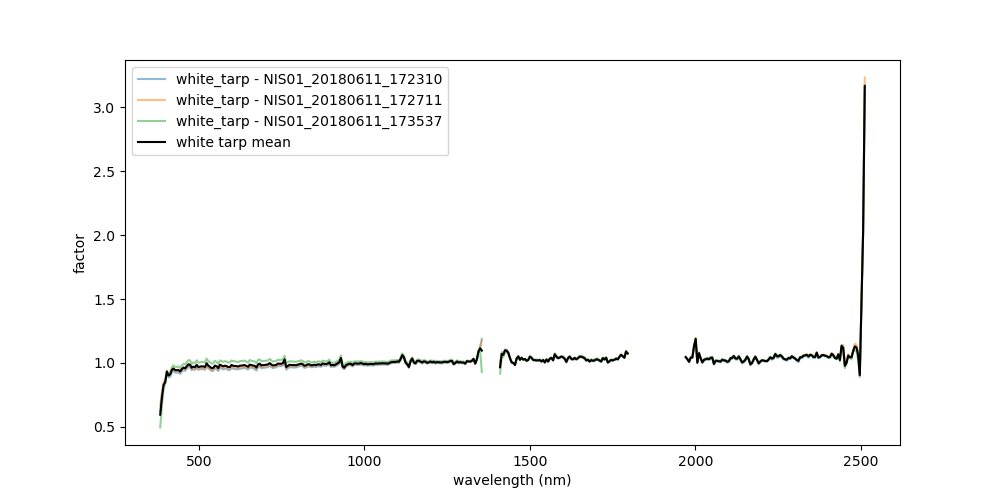

In [29]:
# viz all of the factors together

fig = plt.figure(figsize=(10,5))

for k in ['white_tarp', 'black_tarp']:
    for flight in rccs.keys():
        try:
            rcc_ = rccs[flight][k]
            if k=='white_tarp':
                plt.plot(wl_nan, rcc_, label=f'{k} - {flight}', alpha=0.5)
            else: pass
            
        except: pass
plt.plot(wl_nan, rcc_white_tarp_mean, color='black', label='white tarp mean')
plt.xlabel('wavelength (nm)')
plt.ylabel('factor')
plt.legend()
plt.show()

# plt.savefig(os.path.join(out_figs, f'rccs_20250829.png'), dpi=300)

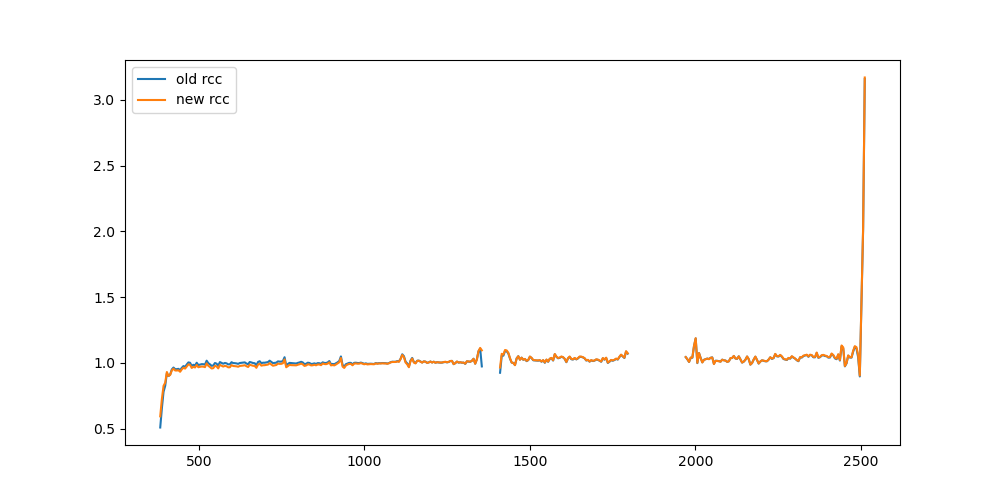

In [25]:
# visualize difference between new and old rccs (state vs alg solution)

rcc_mean_old = np.loadtxt(os.path.join(home, '2018/test_roi/rcc_white_tarp_mean_20250807.txt')) # mean across 4 calibration flightlines
rcc_mean = np.loadtxt(os.path.join(home, '2018/test_roi/rcc_white_tarp_mean_20250829.txt')) # mean across 4 calibration flightlines

fig = plt.figure(figsize=(10,5))
plt.plot(wl_nan, rcc_mean_old, label='old rcc')
plt.plot(wl_nan, rcc_mean, label='new rcc')
plt.legend()
plt.show()